# 4 — Convolutions and CNNs

In this notebook we will:

1. Recap **why convolutions** suit image data where fully-connected layers do not.
2. Implement **1-D and 2-D convolution** as `numpy` loops — by hand — and study hand-designed kernels.
3. Apply those kernels to a real image, and implement **pooling**.
4. Train two real classifiers on **MNIST** — a fully-connected **MLP** and the convolutional **LeNet** — with PyTorch, and compare them.

Sections §1–§3 use only `numpy`: every convolution is a loop you write by hand. Section §4 switches to `torch.nn`, because training a network means **backpropagation**, which is impractical to derive and code by hand for convolutional layers — this mirrors the step from notebook 1 (the perceptron by hand) to notebook 3 (the perceptron with `torch.nn`).

Suggested reading: `lectures/9-1989-cnn.pdf` introduces every operation in this notebook.

## Recap — why convolutions?

An image is a **matrix of pixels**. A grayscale pixel carries a single intensity; a colour pixel carries three (red, green, blue) — its **channels**.

A fully-connected network (an MLP) treats its input as an *unstructured* vector: every input value is wired to every neuron. For images this has two drawbacks.

- **Parameter explosion.** A single hidden neuron connected to every pixel of a $100 \times 100$ colour image already needs $3 \cdot 100 \cdot 100 = 30{,}000$ weights.
- **No use of structure.** Pixel values are *not* independent: nearby pixels are strongly correlated, and a meaningful pattern — an edge, a corner — is **local**. An MLP ignores this entirely.

A **convolutional layer** exploits exactly this structure. Each neuron looks only at a small local patch of the input — its *receptive field* — and the **same** small set of weights is reused at every position. This is an **inductive bias**: prior knowledge about images, wired into the architecture.

The idea has two roots. Biologically, Hubel and Wiesel (1960s) found that the mammalian visual cortex is a *hierarchy* of detectors — simple cells fire on oriented edges, later cells on increasingly complex shapes. Computationally, Yann LeCun's **LeNet** (1989, 1998) turned this hierarchy into a trainable network that read handwritten ZIP codes for the US Postal Service — the first CNN deployed at industrial scale.

### Exercise 0 (paper) — the parameter argument

Make the "parameter explosion" precise. Consider a $3$-channel $100 \times 100$ image.

1. An MLP whose first hidden layer has $10$ neurons, each connected to **every** input value. How many weights does that layer hold?
2. A convolutional layer with $10$ filters, each a $3 \times 3$ kernel applied across all $3$ channels. How many weights?
3. Take the ratio. How does each count change if the image is enlarged to $1000 \times 1000$?


**Answer.**

1. The input has $3 \cdot 100 \cdot 100 = 30{,}000$ values. Each of the $10$ neurons holds one weight per input value: $30{,}000 \cdot 10 = 300{,}000$ weights.
2. Each filter spans $3 \times 3$ over $3$ channels: $3 \cdot 3 \cdot 3 = 27$ weights. Ten filters: $27 \cdot 10 = 270$ weights.
3. The ratio is $300{,}000 / 270 \approx 1100$. Enlarging the image to $1000 \times 1000$ multiplies the **MLP** count by $100$ (to $30$ million), while the **convolutional** count stays at $270$ — a convolutional layer's parameter count is *independent of the input size*. We verify this in code below.

## The convolution operator

Convolutional networks are built on the mathematical operation of **convolution**. We start in one dimension.

Given an input signal $x$ and a **kernel** (or *filter*) $\omega$, their convolution is a new signal $z$. In the continuous case it is an integral; in the discrete case — the one we need — a sum:

\begin{aligned}
    z(t) &\;=\; (x * \omega)(t) \;=\; \int_{-\infty}^{\infty} x(\tau)\,\omega(t - \tau) \\
    z(t) &\;=\; (x * \omega)(t) \;=\; \sum_{\tau = -\infty}^{\infty} x(\tau)\,\omega(t - \tau). 
\end{aligned}

This is a different operator than the **cross-correlation** $(x \star \omega)(t)$, where the input signal $x(\tau)$ is weighted by $\omega(t+\tau)$. A simple difference that highlights the answer to two different questions:

- **Cross-correlation** is more like pattern-matching, i.e., it answers the question: "*How similar are these two signals?*"
- **Convolution**, on the other hand, answer the following: “*How much does an event from $\tau$ time ago contribute now at time $t$?*” In this case, $x(\tau)$ is the value of our input singnal $\tau$ time ago, $\omega(t-\tau)$ says how much an input at time $\tau$ affects the output at time $t$, with the elapsed time being $t-\tau$ 

In practice the kernel is short — nonzero only over a few entries. For a size-$3$ kernel $\omega = (\omega_1, \omega_2, \omega_3)$ and a signal $x = (x_1, x_2, \dots)$, each output is a **local weighted sum**:

$$ z_i \;=\; \omega_1\, x_{i-1} \;+\; \omega_2\, x_i \;+\; \omega_3\, x_{i+1}. $$

The kernel slides across the signal; at every position it produces one weighted sum of the values beneath it.

**A note on terminology.** CNNs technically compute *cross-correlation* — the kernel is **not** flipped, as a textbook convolution would require. The distinction does not matter here: in a CNN the kernel is *learned*, so a flipped kernel is just a relabelling of the weights. We follow the CNN convention (no flip) throughout, and keep the name `conv`, as is standard in deep learning.

In [1]:
# Imports

import matplotlib.pyplot as plt
import numpy as np

## §1 — 1-D convolution

A 1-D convolution slides a kernel along a univariate signal — a time series, an audio waveform, the intensity profile of one image row. Three parameters control the sliding:

- **Padding.** The kernel needs a full window of values at every position. Near the ends of the signal that window runs off the edge. *Zero-padding* prepends and appends zeros so the output keeps the input length; *valid* convolution uses no padding and produces a shorter output.
- **Stride.** How far the kernel moves between two consecutive positions. The default is $1$; a larger stride skips positions and shortens the output.
- **Dilation.** A gap inserted between the kernel taps. A dilated kernel covers a wider span of the signal — a larger *receptive field* — without using more weights.

With an input of length $L$, a kernel of size $K$, padding $p$, stride $s$ and dilation $d$, the kernel's effective span is $(K-1)\,d + 1$, and the output has length

$$ L_{\text{out}} \;=\; \left\lfloor \frac{L + 2p - \bigl((K-1)\,d + 1\bigr)}{s} \right\rfloor + 1. $$

Output position $i$ (counting from $0$) reads the padded signal starting at index $i\,s$ and steps through the $K$ kernel taps spaced $d$ apart:

$$ z_i \;=\; \sum_{j=0}^{K-1} x^{\text{pad}}_{\,i\,s \,+\, j\,d}\;\; \omega_j. $$

<p align="center"> 
    <img src="../imgs/9-1989-cnn/kernel_stride_pad.png" style="width:80%; max-width:800px;">
</p>

### Exercise 1 — implement `conv1d`

Implement the 1-D convolution (cross-correlation) as a plain `numpy` loop.

```python
def conv1d(x, k, padding=0, stride=1, dilation=1):
    """1-D cross-correlation of signal x with kernel k. Returns a 1-D array."""
    ...
```

Do **not** use `np.convolve` or `scipy` — the point is to write the sliding sum yourself.

In [2]:
def conv1d(x, k, padding=0, stride=1, dilation=1):
    """1-D cross-correlation of signal x with kernel k. Returns a 1-D array."""
    x = np.asarray(x, dtype=float)
    k = np.asarray(k, dtype=float)
    K = len(k)
    eff_k = (K - 1) * dilation + 1  # effective kernel span
    x_pad = np.pad(x, padding)  # zero-padding on both sides
    n_out = (len(x_pad) - eff_k) // stride + 1
    z = np.zeros(n_out)
    for i in range(n_out):
        start = i * stride
        acc = 0.0
        for j in range(K):
            acc += x_pad[start + j * dilation] * k[j]
        z[i] = acc
    return z

In [3]:
# A reusable helper: stem-plot a 1-D signal and the result of convolving it.
def plot_conv1d(ax_in, ax_out, x, z, k_label):
    ax_in.stem(np.arange(len(x)), x, basefmt=" ")
    ax_in.set_title("input $x$")
    ax_in.set_xlabel("$i$")
    ax_in.set_ylabel("$x_i$")
    ax_in.grid(alpha=0.3)

    markerline, stemlines, _ = ax_out.stem(np.arange(len(z)), z, basefmt=" ")
    plt.setp(markerline, color="tab:red")
    plt.setp(stemlines, color="tab:red")
    ax_out.axhline(0, color="black", lw=0.8)
    ax_out.set_title("output $z$ - " + k_label)
    ax_out.set_xlabel("$i$")
    ax_out.set_ylabel("$z_i$")
    ax_out.grid(alpha=0.3)

### Four hand-designed kernels

We test `conv1d` on the signal $x = (1, 3, 2, 5, 4, 1, 2, 6)$ with four classic kernels, each using zero-padding so the output keeps the input length:

| Kernel | $\omega$ | Effect |
|---|---|---|
| Smoothing (moving average) | $\tfrac{1}{3}(1, 1, 1)$ | averages neighbours — attenuates high-frequency variation (a low-pass filter) |
| Edge detection | $(-1, 0, 1)$ | a discrete derivative — large where the signal changes abruptly |
| Sharpening | $(-1, 3, -1)$ | emphasises a value against its neighbours — accentuates peaks |
| Dilated edge detection | $(-1, 0, 1)$, $d = 2$ | the same edge detector with a wider reach — same weights, larger receptive field |

Each kernel *is* a feature detector. In a CNN these weights are not chosen by hand — they are **learned from data**.

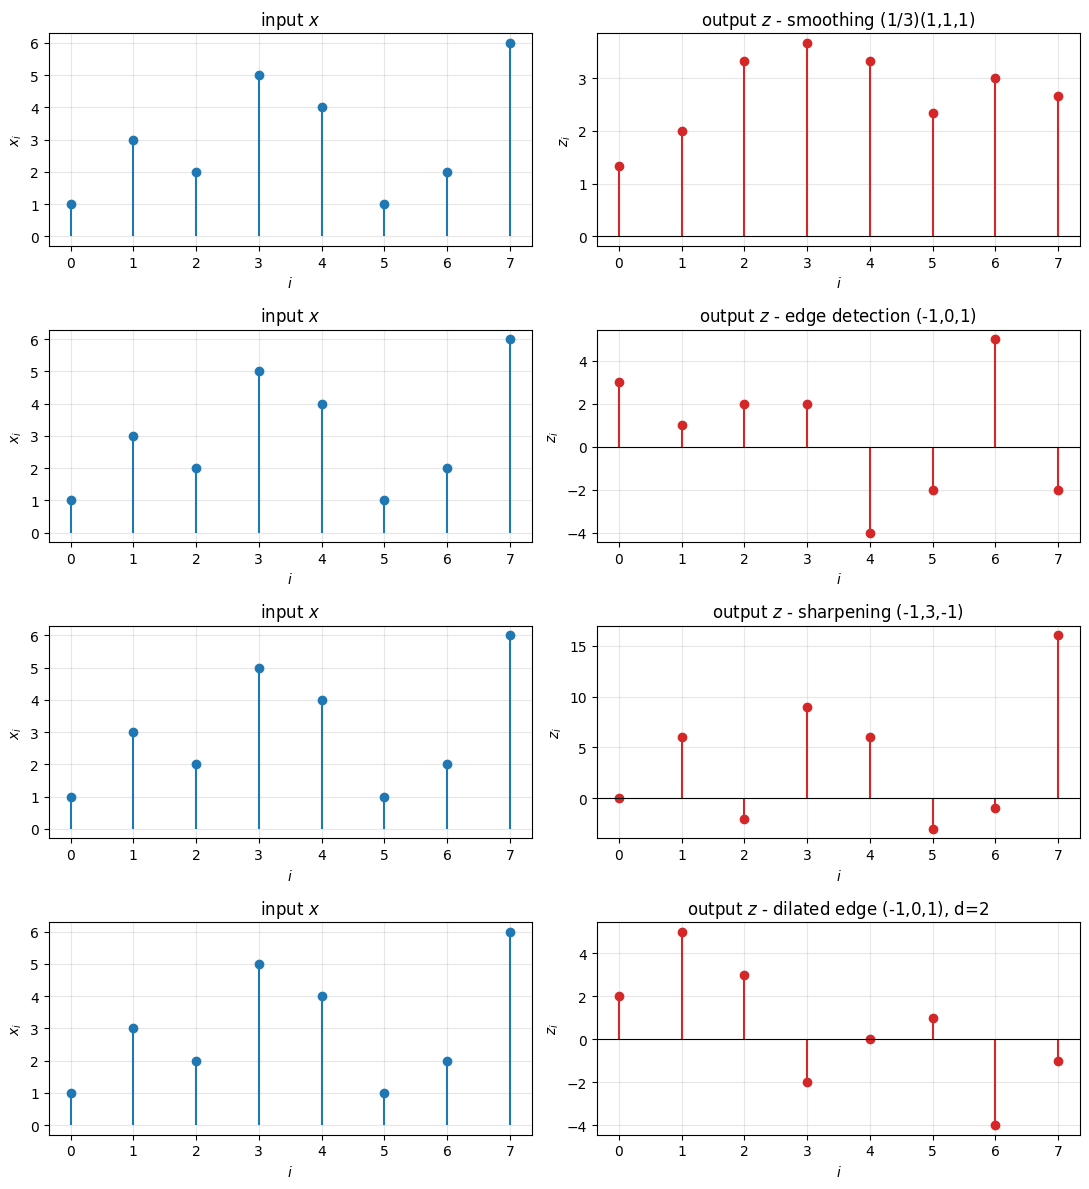

smoothing output z = [1.33 2.   3.33 3.67 3.33 2.33 3.   2.67]
expected (lecture) = [1.33 2.   3.33 3.67 3.33 2.33 3.   2.67]


In [4]:
x = np.array([1, 3, 2, 5, 4, 1, 2, 6], dtype=float)

runs = [
    ("smoothing (1/3)(1,1,1)", np.array([1.0, 1.0, 1.0]) / 3, dict(padding=1)),
    ("edge detection (-1,0,1)", np.array([-1.0, 0.0, 1.0]), dict(padding=1)),
    ("sharpening (-1,3,-1)", np.array([-1.0, 3.0, -1.0]), dict(padding=1)),
    (
        "dilated edge (-1,0,1), d=2",
        np.array([-1.0, 0.0, 1.0]),
        dict(padding=2, dilation=2),
    ),
]

fig, axes = plt.subplots(len(runs), 2, figsize=(11, 3 * len(runs)))
for (label, k, kw), (ax_in, ax_out) in zip(runs, axes):
    z = conv1d(x, k, **kw)
    plot_conv1d(ax_in, ax_out, x, z, label)
fig.tight_layout()
plt.show()

# Cross-check the smoothing output against the lecture's numbers.
z_smooth = conv1d(x, np.array([1.0, 1.0, 1.0]) / 3, padding=1)
print("smoothing output z =", np.round(z_smooth, 2))
print("expected (lecture) = [1.33 2.   3.33 3.67 3.33 2.33 3.   2.67]")

### A longer signal

On a short toy signal the effect of a kernel is hard to see. The same two operations — smoothing and edge detection — are far more telling on a longer, noisy signal: a sine wave with a sharp step, corrupted by random noise.

- Smoothing removes the noise (a low-pass filter).
- Edge detection of the smoothed signal then fires sharply at the step, where the signal jumps, and stays near zero over the slowly-varying sine.

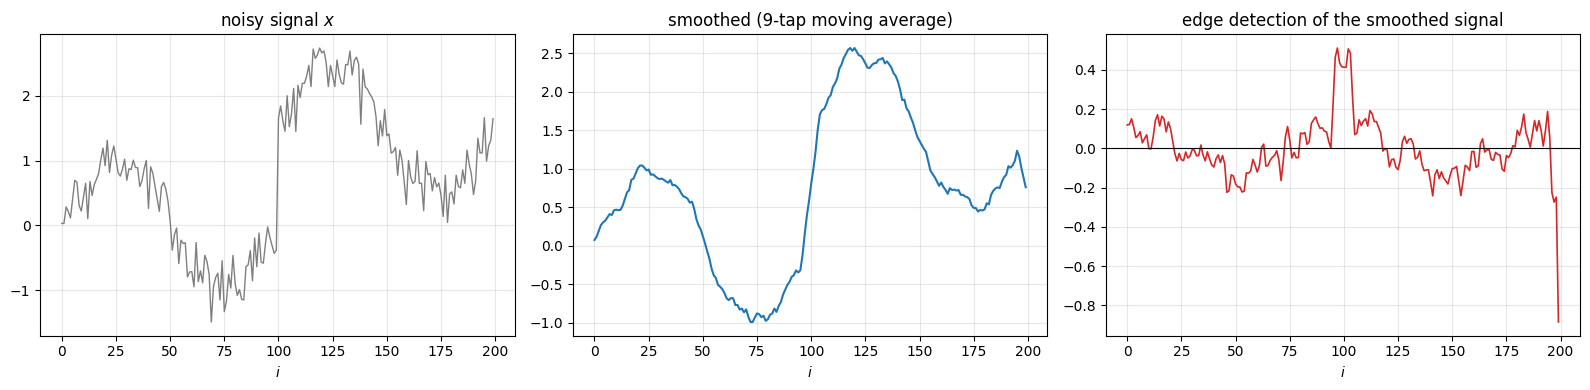

In [5]:
rng = np.random.default_rng(0)
t = np.linspace(0, 4 * np.pi, 200)
clean = np.sin(t) + (t > 2 * np.pi).astype(float) * 1.5  # a sine wave with a step
signal = clean + rng.normal(0, 0.25, size=t.size)  # corrupted by noise

smoothed = conv1d(signal, np.ones(9) / 9, padding=4)  # 9-tap moving average
edges = conv1d(smoothed, np.array([-1.0, 0.0, 1.0]), padding=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(signal, color="tab:gray", lw=1)
axes[0].set_title("noisy signal $x$")
axes[1].plot(smoothed, color="tab:blue", lw=1.5)
axes[1].set_title("smoothed (9-tap moving average)")
axes[2].plot(edges, color="tab:red", lw=1.2)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("edge detection of the smoothed signal")
for ax in axes:
    ax.set_xlabel("$i$")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## A convolutional layer: weight sharing

A 1-D convolution becomes a network **layer** when two ingredients are added: a **bias** $b$ and a non-linear **activation** $\Phi$ (such as ReLU, $\Phi(u) = \max(0, u)$). With a size-$3$ kernel the layer's $i$-th output is

$$ h_i \;=\; \Phi\!\left(b + \sum_{j=1}^{3} \omega_j\, x_{i+j-2}\right). $$

The decisive point: the weights $\omega_1, \omega_2, \omega_3$ and the bias $b$ are **shared across every position $i$**. The whole layer uses $3$ weights and $1$ bias, *no matter how long the input is*. A fully-connected layer, by contrast, needs one weight per (input, neuron) pair — its count grows with the input size, exactly as Exercise 0 quantified.

To detect more than one kind of pattern, a layer uses several kernels **in parallel**. Each kernel produces its own output signal — a **feature map** — and the maps are stacked into **channels**. A multi-channel input (e.g. the RGB channels of an image) is handled symmetrically: each kernel spans all input channels at once.

In [6]:
# Verify Exercise 0: a conv layer's weight count does not depend on input size.
for L in [100, 1_000, 100_000]:
    fc_weights = L * 10  # MLP: 10 neurons, each wired to all L inputs
    conv_weights = 3 * 10  # 10 kernels of size 3 — independent of L
    print(
        f"input length {L:>7,d}:  fully-connected = {fc_weights:>9,d} weights"
        f"   |   convolutional = {conv_weights:>3,d} weights"
    )

input length     100:  fully-connected =     1,000 weights   |   convolutional =  30 weights
input length   1,000:  fully-connected =    10,000 weights   |   convolutional =  30 weights
input length 100,000:  fully-connected = 1,000,000 weights   |   convolutional =  30 weights


## §2 — 2-D convolution

An image is a 2-D signal, so its kernel is a 2-D array — typically a small square matrix. The kernel slides across the image in both directions; at each position it produces one weighted sum of the patch beneath it.

With a $3 \times 3$ kernel $\omega$ and an image $x$ with entries $x_{ij}$, the output is

$$ z_{ij} \;=\; \sum_{m=1}^{3}\sum_{n=1}^{3} \omega_{mn}\; x_{\,i+m-2,\;j+n-2}. $$

Padding, stride and dilation carry over from the 1-D case, applied to both axes.

**Displaying the output.** A convolution sums signed, weighted neighbours, so an output pixel $z_{ij}$ can be *any* real number — negative, or larger than the input range $[0, 255]$. The result is therefore no longer an image in the literal sense; it is a **signed scalar field**. To display it as an image we adopt the convention

$$ z_{ij} \;\longmapsto\; \min\bigl(|z_{ij}|,\; 255\bigr): $$

take the absolute value, then clip to $[0, 255]$.

<p align="center"> 
    <img src="../imgs/9-1989-cnn/cnn_kernels.png" style="width:90%;">
</p>

### Exercise 2 — implement `conv2d`

Extend `conv1d` to two dimensions.

```python
def conv2d(X, K, padding=0, stride=1, dilation=1):
    """2-D cross-correlation of image X with kernel K. Returns a 2-D array."""
    ...
```

The structure mirrors `conv1d`: pad both axes, compute the output height and width with the same formula applied per axis, then for each output pixel sum the kernel against the patch beneath it. Plain `numpy` loops, no shortcuts.

In [7]:
def conv2d(X, K, padding=0, stride=1, dilation=1):
    """2-D cross-correlation of image X with kernel K. Returns a 2-D array."""
    X = np.asarray(X, dtype=float)
    K = np.asarray(K, dtype=float)
    kh, kw = K.shape
    eff_h = (kh - 1) * dilation + 1
    eff_w = (kw - 1) * dilation + 1
    X_pad = np.pad(X, padding)
    H, W = X_pad.shape
    out_h = (H - eff_h) // stride + 1
    out_w = (W - eff_w) // stride + 1
    Z = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            r0, c0 = i * stride, j * stride
            acc = 0.0
            for m in range(kh):
                for n in range(kw):
                    acc += X_pad[r0 + m * dilation, c0 + n * dilation] * K[m, n]
            Z[i, j] = acc
    return Z

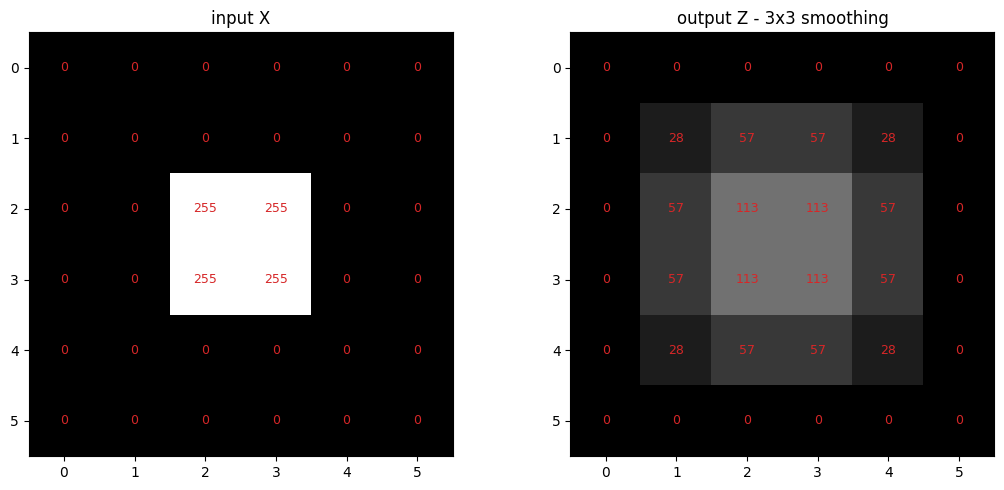

In [8]:
# A tiny synthetic image: a white square on a black background.
small = np.zeros((6, 6))
small[2:4, 2:4] = 255.0

Z_small = conv2d(small, np.ones((3, 3)) / 9, padding=1)  # 3x3 moving average

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, M, title in [
    (axes[0], small, "input X"),
    (axes[1], Z_small, "output Z - 3x3 smoothing"),
]:
    ax.imshow(M, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    for (r, c), v in np.ndenumerate(M):
        ax.text(c, r, f"{v:.0f}", ha="center", va="center", color="tab:red", fontsize=9)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
fig.tight_layout()
plt.show()

### A real image

The numbers above confirm `conv2d` is correct. To see what kernels actually *do*, we need a real photograph. We use a portrait of **Grace Hopper** — a pioneer of computing — which ships with `matplotlib`, so no download is required.

We convert it to grayscale (a weighted average of the RGB channels) and subsample it, to keep the pure-`numpy` convolution loops fast.

image shape: (200, 171),  range: [0, 255]


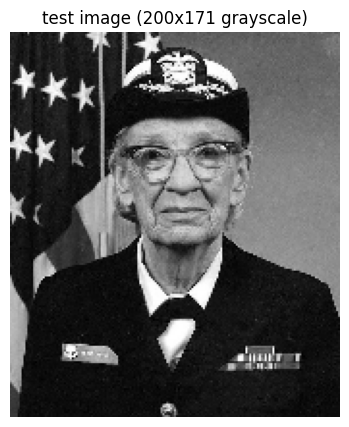

In [9]:
def load_image():
    """Load a grayscale test image in [0, 255]. Falls back to a synthetic
    image if matplotlib's sample data is unavailable."""
    try:
        import matplotlib.cbook as cbook

        path = cbook.get_sample_data("grace_hopper.jpg", asfileobj=False)
        rgb = plt.imread(path).astype(float)
        gray = rgb @ np.array([0.299, 0.587, 0.114])  # luminosity weights
        return gray[::3, ::3]  # subsample for speed
    except Exception:
        # Synthetic fallback: shapes on a gradient background.
        yy, xx = np.mgrid[0:200, 0:200]
        img = (xx + yy) / 1.6
        img[40:90, 40:160] = 240.0
        img[120:170, 60:140] = 30.0
        return img


image = load_image()
print(f"image shape: {image.shape},  range: [{image.min():.0f}, {image.max():.0f}]")

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image, cmap="gray", vmin=0, vmax=255)
ax.set_title(f"test image ({image.shape[0]}x{image.shape[1]} grayscale)")
ax.axis("off")
plt.show()

In [10]:
# A reusable helper: show input, signed output, and the displayable |Z| clipped to [0, 255].
def show_conv2d(X, K, title, **conv_kw):
    Z = conv2d(X, K, **conv_kw)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(X, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("input X")

    lim = np.abs(Z).max()
    im = axes[1].imshow(Z, cmap="bwr", vmin=-lim, vmax=lim)
    axes[1].set_title(f"signed output Z  [{Z.min():.0f}, {Z.max():.0f}]")
    fig.colorbar(im, ax=axes[1], fraction=0.046)

    axes[2].imshow(np.minimum(np.abs(Z), 255), cmap="gray", vmin=0, vmax=255)
    axes[2].set_title("displayed: min(|Z|, 255)")

    for ax in axes:
        ax.axis("off")
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()
    return Z

### Hand-designed 2-D kernels

The image-processing kernels below have been known for decades. Each detects a specific kind of structure:

- **Smoothing** — a box average; non-negative weights summing to $1$, so the output is a blurred version of the input.
- **Sobel-x / Sobel-y** — discrete derivatives along one axis; they detect **vertical** and **horizontal** edges respectively. Their weights sum to $0$, so flat regions give $0$.
- **Laplacian** — an isotropic outline detector; it fires on any change, regardless of orientation.
- **Sharpening** — boosts a pixel against its neighbours; weights sum to $1$, so flat regions are preserved while edges are accentuated.
- **Emboss** — an anti-symmetric kernel that responds to edges along one diagonal, producing a 3-D relief effect.

The kernels are collected in a dictionary below.

In [11]:
KERNELS = {
    "smoothing 3x3": np.ones((3, 3)) / 9,
    "smoothing 5x5": np.ones((5, 5)) / 25,
    "Sobel-x": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float),
    "Sobel-y": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float),
    "Laplacian": np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=float),
    "sharpen": np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=float),
    "emboss": np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=float),
}
for name, K in KERNELS.items():
    print(f"{name:>13s}:  shape {K.shape},  sum {K.sum():+.2f}")

smoothing 3x3:  shape (3, 3),  sum +1.00
smoothing 5x5:  shape (5, 5),  sum +1.00
      Sobel-x:  shape (3, 3),  sum +0.00
      Sobel-y:  shape (3, 3),  sum +0.00
    Laplacian:  shape (3, 3),  sum +0.00
      sharpen:  shape (3, 3),  sum +1.00
       emboss:  shape (3, 3),  sum +1.00


### Reading a signed output

The Sobel-x kernel is a good case for inspecting the *signed* output before it is collapsed to a displayable image. A positive response marks a dark-to-light transition along the row; a negative one, a light-to-dark transition. The three-panel helper shows, left to right: the input, the signed field (red positive, blue negative), and the displayed $\min(|Z|, 255)$.

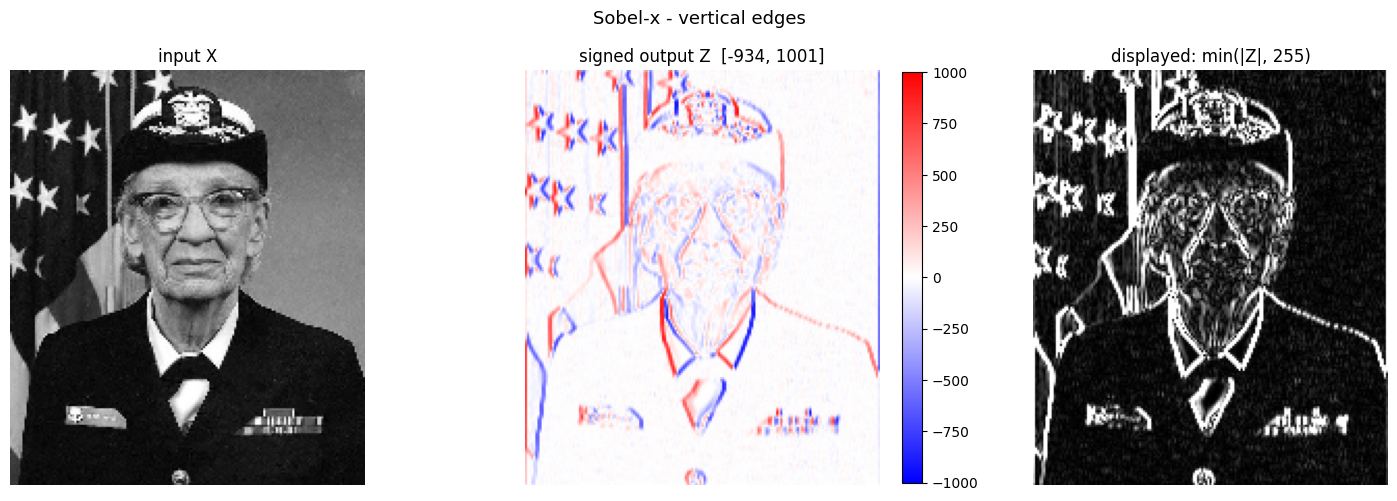

In [12]:
_ = show_conv2d(image, KERNELS["Sobel-x"], "Sobel-x - vertical edges", padding=1)

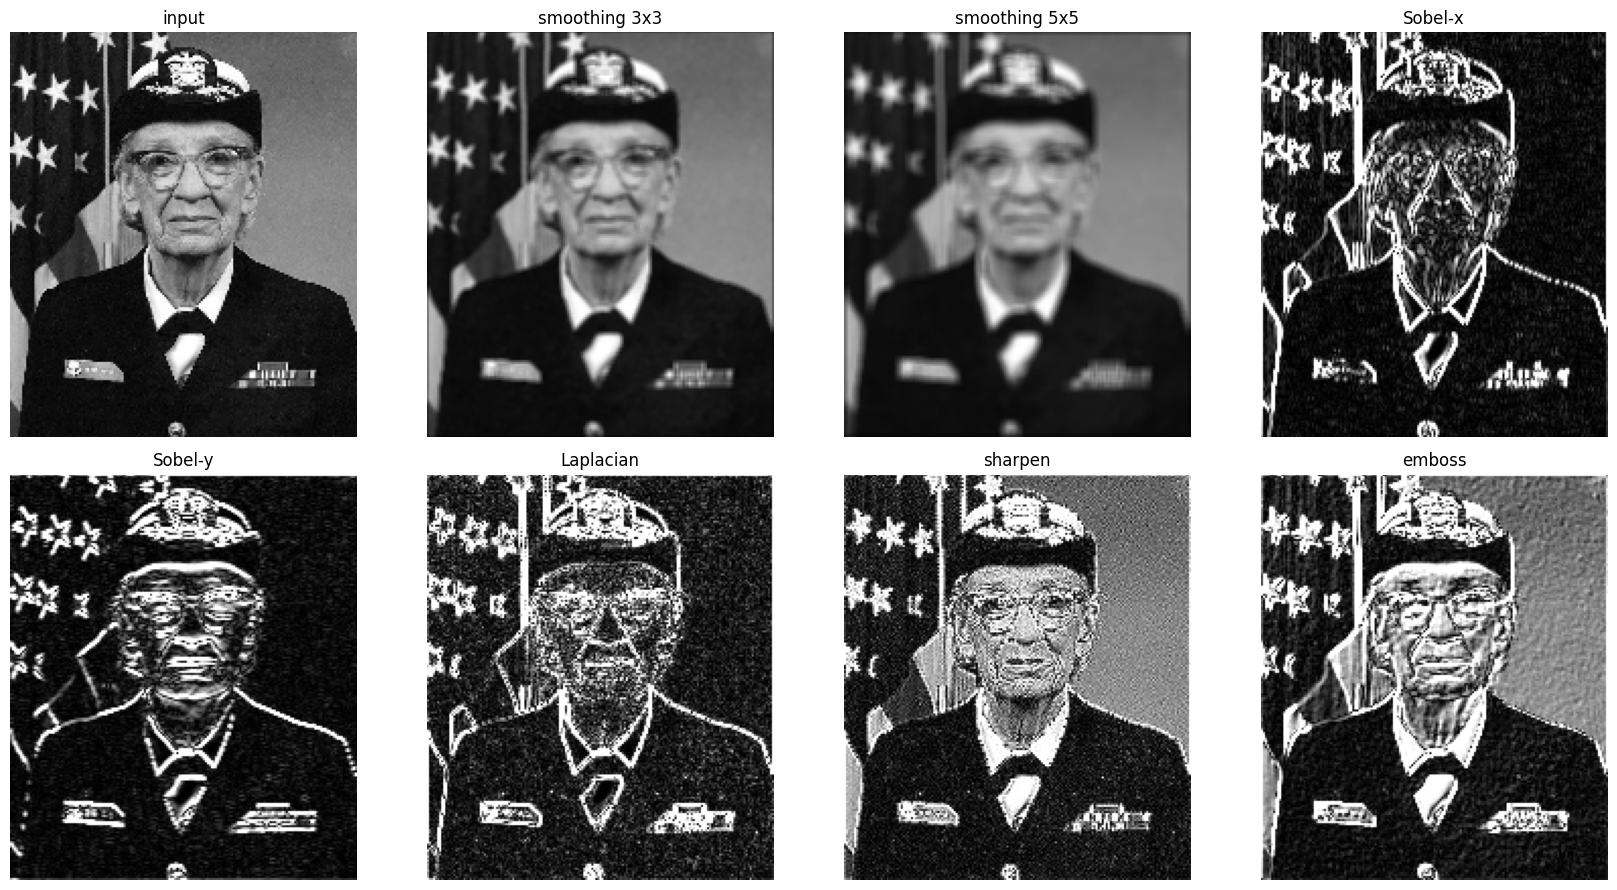

In [13]:
# Apply every kernel and show the displayed output min(|Z|, 255).
fig, axes = plt.subplots(2, 4, figsize=(17, 9))
axes = axes.ravel()

axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("input")
axes[0].axis("off")

for ax, (name, K) in zip(axes[1:], KERNELS.items()):
    pad = K.shape[0] // 2
    Z = conv2d(image, K, padding=pad)
    ax.imshow(np.minimum(np.abs(Z), 255), cmap="gray", vmin=0, vmax=255)
    ax.set_title(name)
    ax.axis("off")
fig.tight_layout()
plt.show()

### Exercise 3 — gradient magnitude

Sobel-x detects vertical edges, Sobel-y horizontal ones. Each alone is *orientation-dependent*: it misses edges that run parallel to its axis. Combining them removes the dependence. The **gradient magnitude**

$$ G_{ij} \;=\; \sqrt{(Z^x_{ij})^2 + (Z^y_{ij})^2} $$

is large wherever the image changes, *regardless of edge orientation* — here $Z^x$ and $Z^y$ are the Sobel-x and Sobel-y outputs.

Implement it:

```python
def gradient_magnitude(X):
    """Orientation-independent edge strength via Sobel-x and Sobel-y."""
    ...
```

In [14]:
def gradient_magnitude(X):
    """Orientation-independent edge strength via Sobel-x and Sobel-y."""
    Zx = conv2d(X, KERNELS["Sobel-x"], padding=1)
    Zy = conv2d(X, KERNELS["Sobel-y"], padding=1)
    return np.sqrt(Zx**2 + Zy**2)

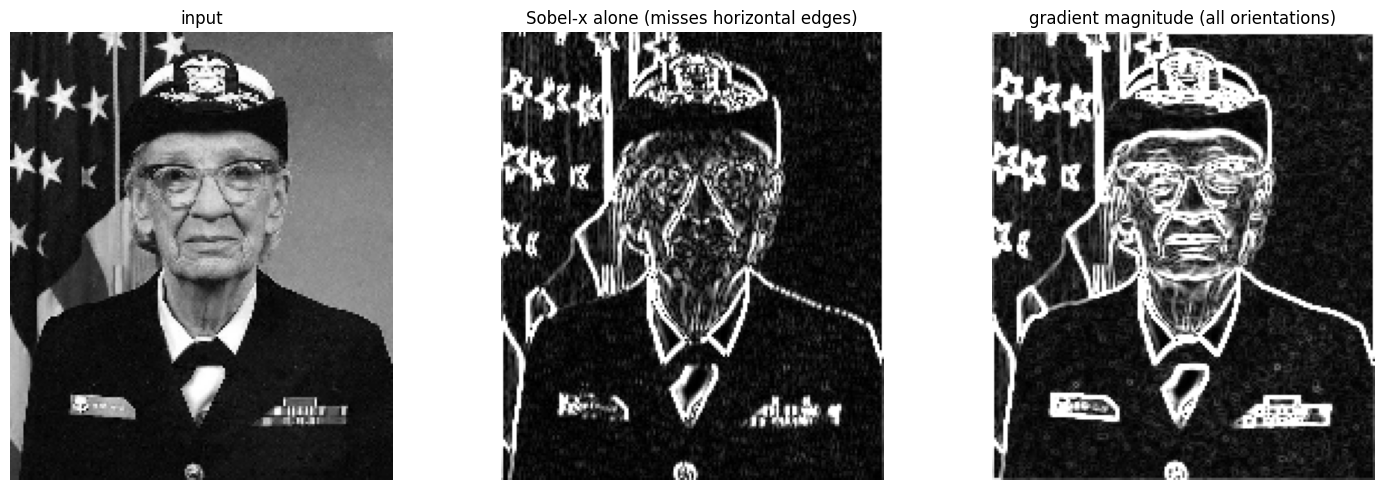

In [15]:
G = gradient_magnitude(image)
Zx_only = np.minimum(np.abs(conv2d(image, KERNELS["Sobel-x"], padding=1)), 255)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, M, title in [
    (axes[0], image, "input"),
    (axes[1], Zx_only, "Sobel-x alone (misses horizontal edges)"),
    (axes[2], np.minimum(G, 255), "gradient magnitude (all orientations)"),
]:
    ax.imshow(M, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()

### Dilation and channels

Two extensions from the lecture, in brief.

**Dilation.** A dilated kernel spaces its taps apart, enlarging the receptive field at no extra parameter cost. A dilated $3 \times 3$ Sobel-x ($d = 2$) spans a $5 \times 5$ region but still holds only $9$ weights; its edge response is correspondingly thicker.

**Channels.** A colour image is a 2-D signal with three channels (R, G, B). A kernel applied to it is itself 3-dimensional — $3 \times 3 \times 3$ — and sums over all channels at once, producing a single 2-D feature map. Using several such kernels in parallel yields several feature maps: the output gains its own channel dimension. This is the general pattern of every convolutional layer in a CNN.

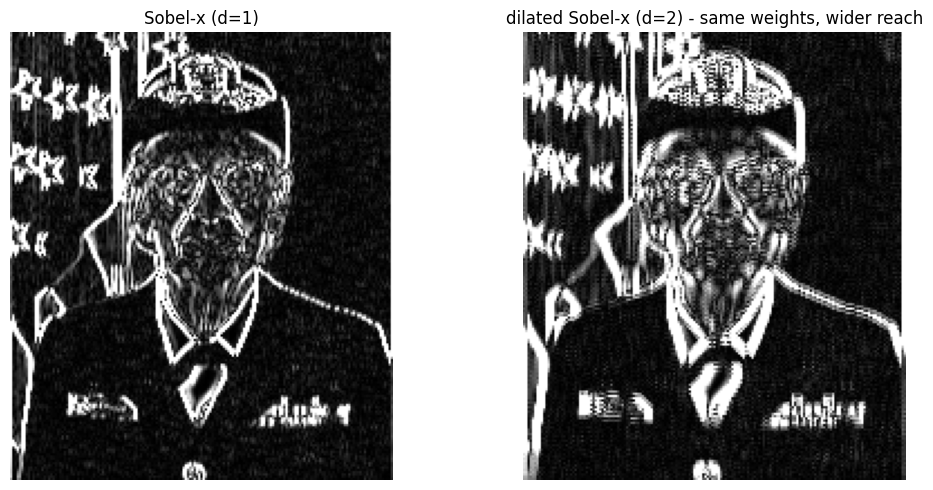

In [16]:
# Dilated Sobel-x (d=2): a wider receptive field and thicker edges, with the same 9 weights.
Z_plain = conv2d(image, KERNELS["Sobel-x"], padding=1)
Z_dilated = conv2d(image, KERNELS["Sobel-x"], padding=2, dilation=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(np.minimum(np.abs(Z_plain), 255), cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Sobel-x (d=1)")
axes[1].imshow(np.minimum(np.abs(Z_dilated), 255), cmap="gray", vmin=0, vmax=255)
axes[1].set_title("dilated Sobel-x (d=2) - same weights, wider reach")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

## From hand-crafted to learned filters

Every kernel used above was chosen by hand, from a fixed vocabulary built up over decades of image processing. The kernel *is* the feature detector — change the nine numbers and you change what the layer responds to.

A CNN keeps the convolution machinery but **does not fix the numbers**. The kernel entries are parameters, learned from data by gradient descent (the algorithm of notebook 2) to minimise a downstream loss. And each layer applies its filters to the *output of the previous layer*, not to the raw image. The result is a hierarchy of increasingly abstract features:

$$ \text{pixels} \;\to\; \text{edges} \;\to\; \text{textures} \;\to\; \text{parts} \;\to\; \text{objects}, $$

the same cascade Hubel and Wiesel observed in the visual cortex (V1 $\to$ V2 $\to$ IT). The early layers typically end up learning edge- and blob-detectors that look much like the Sobel kernels above — discovered, not designed.

## §3 — Downsampling: pooling

Stacked convolutions detect ever more complex patterns, but a $3 \times 3$ kernel still only ever sees a $3 \times 3$ patch of its input. To let later layers integrate information over a wider area — and to cut the amount of computation — a CNN periodically **downsamples**: it reduces the spatial resolution.

Three standard methods, each applied independently per channel:

- **Strided convolution** — convolve with a stride $> 1$, sampling only every few positions. We already have this: `conv2d(..., stride=2)`.
- **Max pooling** — partition the image into small windows and keep the **maximum** of each. Retaining the strongest response gives a degree of *translation invariance*: a small shift of the input leaves the pooled output largely unchanged.
- **Mean pooling** — keep the **average** of each window: a smoother downsampling.

Comparative studies have generally found max pooling to perform best.

### Exercise 4 — implement `pool2d`

```python
def pool2d(X, size=2, stride=2, mode="max"):
    """Downsample X by max- or mean-pooling over size x size windows."""
    ...
```

The output dimensions follow the same formula as a convolution with a `size`-by-`size` kernel (no padding, no dilation). With the default `size=2, stride=2` the windows tile the image without overlap and the output is half the resolution. For each window, return its maximum (`mode="max"`) or its mean (`mode="mean"`).

In [17]:
def pool2d(X, size=2, stride=2, mode="max"):
    """Downsample X by max- or mean-pooling over size x size windows."""
    X = np.asarray(X, dtype=float)
    H, W = X.shape
    out_h = (H - size) // stride + 1
    out_w = (W - size) // stride + 1
    Z = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            window = X[i * stride : i * stride + size, j * stride : j * stride + size]
            Z[i, j] = window.max() if mode == "max" else window.mean()
    return Z

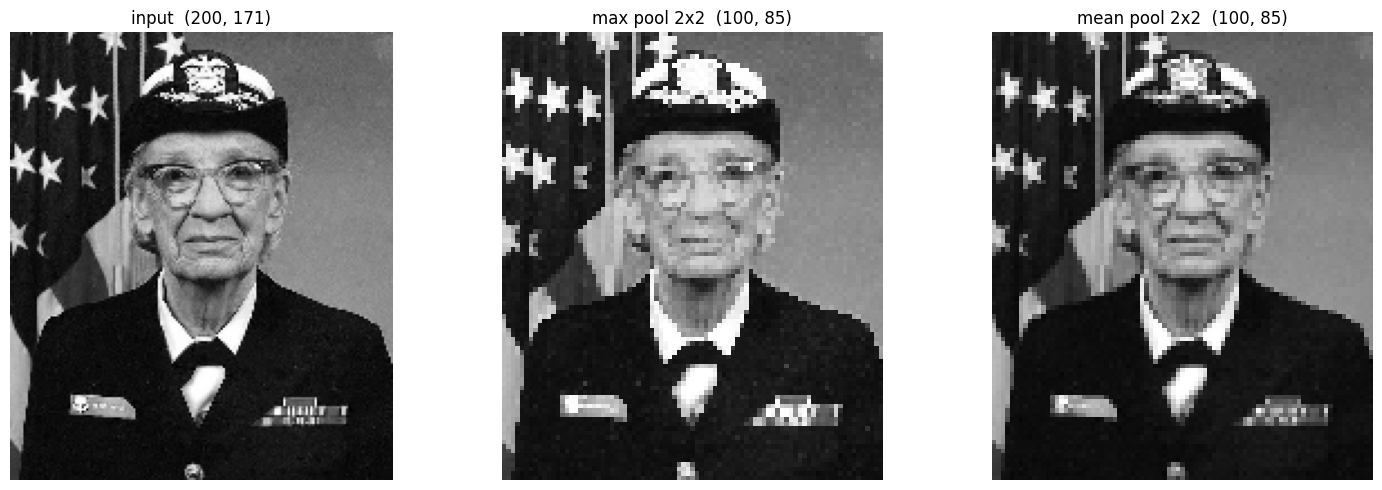

In [18]:
# Max vs mean pooling, and the resolution after each.
pooled_max = pool2d(image, size=2, stride=2, mode="max")
pooled_mean = pool2d(image, size=2, stride=2, mode="mean")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, M, title in [
    (axes[0], image, f"input  {image.shape}"),
    (axes[1], pooled_max, f"max pool 2x2  {pooled_max.shape}"),
    (axes[2], pooled_mean, f"mean pool 2x2  {pooled_mean.shape}"),
]:
    ax.imshow(M, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()

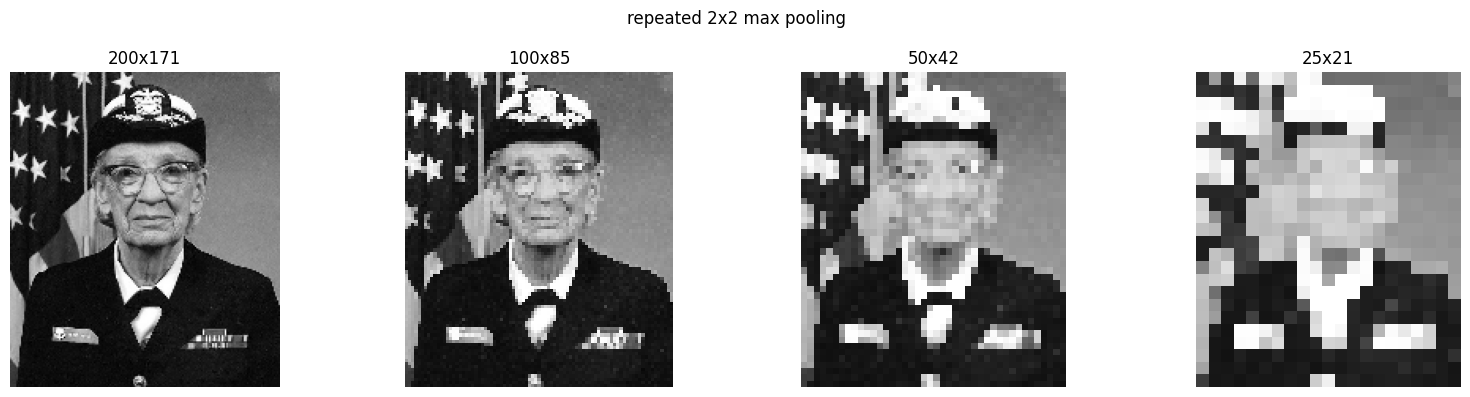

In [19]:
# Repeated max pooling: the spatial resolution halves each time.
stages = [image]
for _ in range(3):
    stages.append(pool2d(stages[-1], size=2, stride=2, mode="max"))

fig, axes = plt.subplots(1, len(stages), figsize=(16, 4))
for ax, M in zip(axes, stages):
    ax.imshow(M, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{M.shape[0]}x{M.shape[1]}")
    ax.axis("off")
fig.suptitle("repeated 2x2 max pooling")
fig.tight_layout()
plt.show()

## A CNN-style pipeline

The pieces are now in place to assemble a miniature feed-forward CNN — by hand, with fixed kernels. A real CNN would *learn* the kernels and stack many more blocks, but the data flow is exactly this:

$$ \text{convolution} \;\to\; \text{ReLU} \;\to\; \text{pooling} \;\to\; \text{convolution} \;\to\; \text{pooling}. $$

We apply an edge filter, rectify it with $\Phi(u) = \max(0, u)$, pool, apply a second filter, and pool again. At each stage the spatial resolution shrinks while the representation grows more abstract — the signature CNN pattern, from LeNet onward.

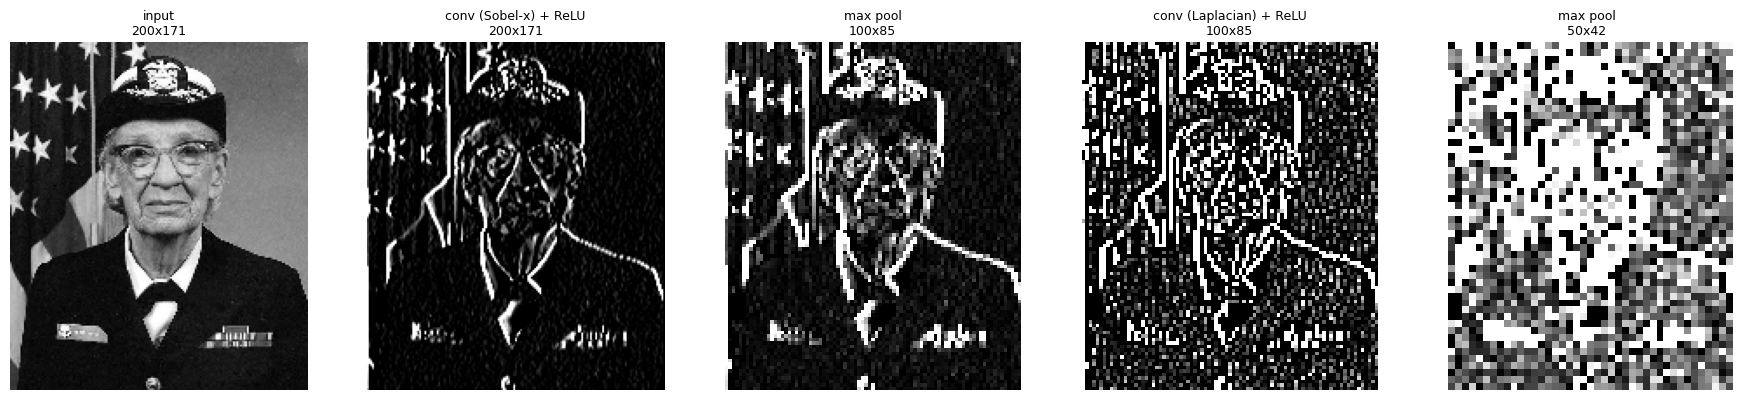

In [20]:
def relu(M):
    return np.maximum(0.0, M)


h0 = image
h1 = relu(conv2d(h0, KERNELS["Sobel-x"], padding=1))  # conv -> ReLU
h2 = pool2d(h1, size=2, stride=2, mode="max")  # pool
h3 = relu(conv2d(h2, KERNELS["Laplacian"], padding=1))  # conv -> ReLU
h4 = pool2d(h3, size=2, stride=2, mode="max")  # pool

stages = [
    (h0, "input"),
    (h1, "conv (Sobel-x) + ReLU"),
    (h2, "max pool"),
    (h3, "conv (Laplacian) + ReLU"),
    (h4, "max pool"),
]
fig, axes = plt.subplots(1, len(stages), figsize=(18, 4))
for ax, (M, title) in zip(axes, stages):
    ax.imshow(np.minimum(M, 255), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{title}\n{M.shape[0]}x{M.shape[1]}", fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

## §4 — From kernels to a trained network: MNIST

Sections §1–§3 built convolution and pooling by hand, with kernels we *chose* — Sobel, Laplacian, and the rest. A real CNN keeps exactly these operations but **learns** the kernels: the nine (or twenty-five) numbers in every filter are parameters, fitted to the data.

Learning them requires the gradient of the loss with respect to every kernel entry — **backpropagation** through the network. Deriving and coding that by hand for convolutional layers is impractical, so from here we hand the mechanics to **PyTorch**: it provides `nn.Conv2d` (a learnable version of the `conv2d` you wrote), automatic differentiation, and optimisers. This is the same step taken from notebook 1, where the perceptron was coded by hand, to notebook 3, where it was rebuilt with `torch.nn`.

We now train two classifiers on **MNIST** and compare them: a fully-connected **MLP**, which ignores the grid structure of an image, and the convolutional **LeNet**, which does not. This reproduces the lecture's CNN-versus-MLP experiment.

### The torch training recipe (recap from notebook 3)

Notebook 3 introduced a single recipe that trains *any* differentiable model. Its four ingredients:

1. **Model** — a subclass of `nn.Module` with `__init__` (build the layers) and `forward` (compute the output from the input).
2. **`Dataset` / `DataLoader`** — the dataset defines a single example; the loader batches and shuffles the data into mini-batches.
3. **Loss** — a differentiable scalar measuring error. For $C$-class classification the standard choice is `nn.CrossEntropyLoss`: it applies the softmax internally, and expects raw **logits** together with integer class labels.
4. **Optimiser** — holds the parameters and the update rule, e.g. `torch.optim.SGD`.

The training **step** is the same four lines for every mini-batch:

```python
optim.zero_grad()                 # 1. clear the previous gradients
logits = model(x_batch)           # 2. forward pass
loss = loss_fn(logits, y_batch)
loss.backward()                   # 3. backward pass — autograd fills every .grad
optim.step()                      # 4. update every parameter
```

Evaluation is wrapped in `torch.no_grad()`: when only *using* the model, no gradients — and no computational graph — are needed.

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.11.0 | device: cpu


### The MNIST dataset

**MNIST** is the benchmark LeNet was built for: $70{,}000$ grayscale images of handwritten digits, $28 \times 28$ pixels, across $10$ classes ($0$–$9$). It was curated by LeCun in the 1990s, out of the postal ZIP-code recognition project. `torchvision` downloads it in one line.

`transforms.ToTensor()` converts each image to a `float` tensor of shape $(1, 28, 28)$ — one channel, $28 \times 28$ pixels — with values in $[0, 1]$. The leading $1$ is the channel dimension every `torch` convolution expects.

train: 60000 images   |   test: 10000 images


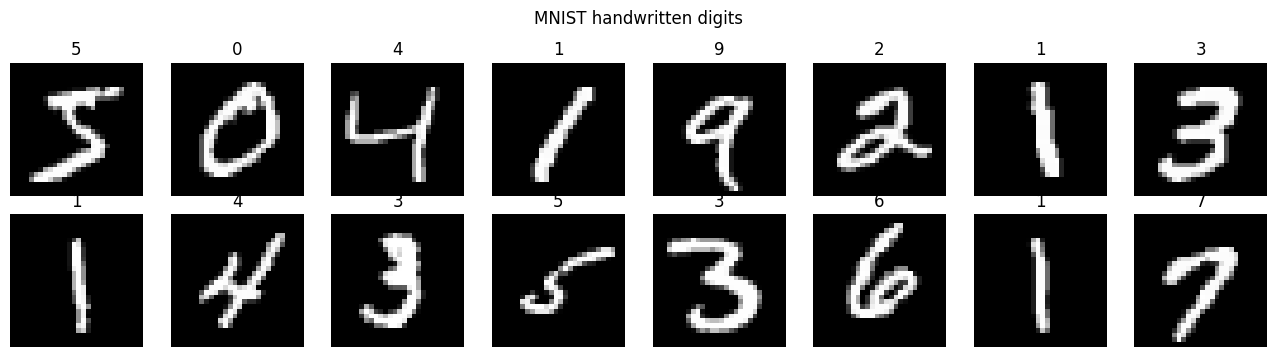

In [22]:
transform = transforms.ToTensor()  # PIL image -> float tensor (1, 28, 28) in [0, 1]

train_full = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_full = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# Training on all 60,000 images takes a couple of minutes on a CPU (seconds on a
# GPU). For a quicker run, set SUBSET to e.g. 20000 to train on a subset.
SUBSET = None
train_set = Subset(train_full, range(SUBSET)) if SUBSET else train_full
test_set = Subset(test_full, range(2000)) if SUBSET else test_full

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)
print(f"train: {len(train_set)} images   |   test: {len(test_set)} images")

fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for ax, (img, label) in zip(axes.ravel(), train_set):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
fig.suptitle("MNIST handwritten digits")
fig.tight_layout()
plt.show()

### Model 1 — a fully-connected MLP

An MLP ignores the grid: it **flattens** the $28 \times 28$ image into a $784$-vector and passes it through fully-connected layers. We use two hidden layers with ReLU activations, with sizes chosen so that the MLP holds **about the same number of parameters as LeNet** (~$62$k):

$$ 784 \;\to\; 72 \;\to\; 64 \;\to\; 10. $$

Matching the parameter budget makes the comparison a test of *architecture*, not of raw capacity. The final layer outputs $10$ logits — one score per digit class.

#### Exercise 5 — implement the MLP

Implement `MLP` as an `nn.Module`, following the pattern from notebook 3. `forward` receives a batch of shape $(B, 1, 28, 28)$ and must return logits of shape $(B, 10)$.

```python
class MLP(nn.Module):
    def __init__(self):
        ...
    def forward(self, x):
        ...   # (B, 1, 28, 28) -> (B, 10)
```

*Hint*: `nn.Flatten()` reshapes $(B, 1, 28, 28)$ into $(B, 784)$; stack `nn.Linear` layers with `nn.ReLU` between them. `nn.Sequential` keeps the definition compact.

In [23]:
class MLP(nn.Module):
    """Fully-connected classifier: flattens the image, ignoring its 2-D structure."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),  # (B, 1, 28, 28) -> (B, 784)
            nn.Linear(784, 72),
            nn.ReLU(),
            nn.Linear(72, 64),
            nn.ReLU(),
            nn.Linear(64, 10),  # 10 logits, one per digit class
        )

    def forward(self, x):
        return self.net(x)

### Model 2 — LeNet

**LeNet-5** (LeCun et al., 1998) is the original CNN. It keeps the image as a 2-D grid and alternates **convolution** and **pooling** — the pipeline of §3, but with *learned* kernels — before a small fully-connected classifier. The architecture, adapted to the $28 \times 28$ MNIST input (the original used $32 \times 32$):

| Layer | Operation | Output shape |
|---|---|---|
| input | — | $1 \times 28 \times 28$ |
| C1 | convolution $5 \times 5$, $6$ filters, padding $2$ | $6 \times 28 \times 28$ |
| S2 | average pool $2 \times 2$ | $6 \times 14 \times 14$ |
| C3 | convolution $5 \times 5$, $16$ filters | $16 \times 10 \times 10$ |
| S4 | average pool $2 \times 2$ | $16 \times 5 \times 5$ |
| F5 | flatten, then linear | $120$ |
| F6 | linear | $84$ |
| output | linear | $10$ |

Activations are `tanh`, as in the original LeNet-5 (modern CNNs use ReLU — the lecture's closing notes the change). The signature CNN pattern is visible in the shapes: the **spatial size shrinks** ($28 \to 14 \to 10 \to 5$) while the **channel count grows** ($1 \to 6 \to 16$).

#### Exercise 6 — implement LeNet

Implement `LeNet` as an `nn.Module` following the table.

```python
class LeNet(nn.Module):
    def __init__(self):
        ...
    def forward(self, x):
        ...   # (B, 1, 28, 28) -> (B, 10)
```

*Hint*: the building blocks are `nn.Conv2d(in_channels, out_channels, kernel_size, padding=...)`, `nn.AvgPool2d(2)`, `nn.Linear`, and `torch.tanh`. After S4 the tensor is $(B, 16, 5, 5)$; `torch.flatten(x, start_dim=1)` turns it into the $(B, 400)$ vector that F5 expects.

In [24]:
class LeNet(nn.Module):
    """LeNet-5 (LeCun et al., 1998) — the original convolutional network."""

    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)  # 1x28x28 -> 6x28x28
        self.c3 = nn.Conv2d(6, 16, kernel_size=5)  # 6x14x14 -> 16x10x10
        self.pool = nn.AvgPool2d(2)  # halves the spatial size
        self.f5 = nn.Linear(16 * 5 * 5, 120)
        self.f6 = nn.Linear(120, 84)
        self.out = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.tanh(self.c1(x)))  # C1 -> S2
        x = self.pool(torch.tanh(self.c3(x)))  # C3 -> S4
        x = torch.flatten(x, start_dim=1)  # (B, 16, 5, 5) -> (B, 400)
        x = torch.tanh(self.f5(x))  # F5
        x = torch.tanh(self.f6(x))  # F6
        return self.out(x)  # (B, 10) logits

### Training both models

The `train`, `evaluate` and `count_params` helpers below are the notebook-3 recipe, verbatim. Nothing in them is model-specific — the *same* loop trains the MLP and LeNet unchanged. That uniformity is the point of the `nn.Module` abstraction.

In [25]:
def evaluate(model, loader):
    """Fraction of correctly classified images in `loader`."""
    model.eval()
    correct = total = 0
    with torch.no_grad():  # no gradients needed to evaluate
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.numel()
    return correct / total


def train(model, epochs=6, lr=0.03):
    """Train `model` on MNIST with the notebook-3 recipe. Returns the test-accuracy
    history (accuracy before training, then one entry per epoch)."""
    model.to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = [evaluate(model, test_loader)]
    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optim.zero_grad()  # 1. clear the previous gradients
            loss = loss_fn(model(x), y)  # 2. forward pass + loss
            loss.backward()  # 3. backward pass (autograd)
            optim.step()  # 4. update every parameter
        acc = evaluate(model, test_loader)
        history.append(acc)
        print(f"  epoch {epoch}:  test accuracy = {acc:.4f}")
    return history


def count_params(model):
    """Total number of learnable parameters."""
    return sum(p.numel() for p in model.parameters())

In [26]:
mlp = MLP()
print(f"MLP — {count_params(mlp):,} parameters")
mlp_history = train(mlp)

MLP — 61,842 parameters
  epoch 1:  test accuracy = 0.9502
  epoch 2:  test accuracy = 0.9653
  epoch 3:  test accuracy = 0.9660
  epoch 4:  test accuracy = 0.9694
  epoch 5:  test accuracy = 0.9618
  epoch 6:  test accuracy = 0.9736


In [27]:
lenet = LeNet()
print(f"LeNet — {count_params(lenet):,} parameters")
lenet_history = train(lenet)

LeNet — 61,706 parameters
  epoch 1:  test accuracy = 0.9756
  epoch 2:  test accuracy = 0.9832
  epoch 3:  test accuracy = 0.9834
  epoch 4:  test accuracy = 0.9837
  epoch 5:  test accuracy = 0.9856
  epoch 6:  test accuracy = 0.9873


### MLP versus LeNet

The lecture's experiment, reproduced. The two models are given **the same parameter budget** (~$62$k), so the comparison isolates one variable: the *architecture*. The MLP flattens the image and wires every pixel to every neuron; LeNet keeps the 2-D grid and exploits locality and weight sharing.

MNIST is an easy dataset, so both reach high accuracy — but with an essentially identical number of parameters LeNet reaches a markedly lower error rate. The advantage comes purely from the **inductive bias**: the convolutional architecture matches how images are structured. On harder data the gap widens sharply — the lecture reports a $17\%$-versus-$40\%$ test-error gap on a noisier $1$-D variant of the task.

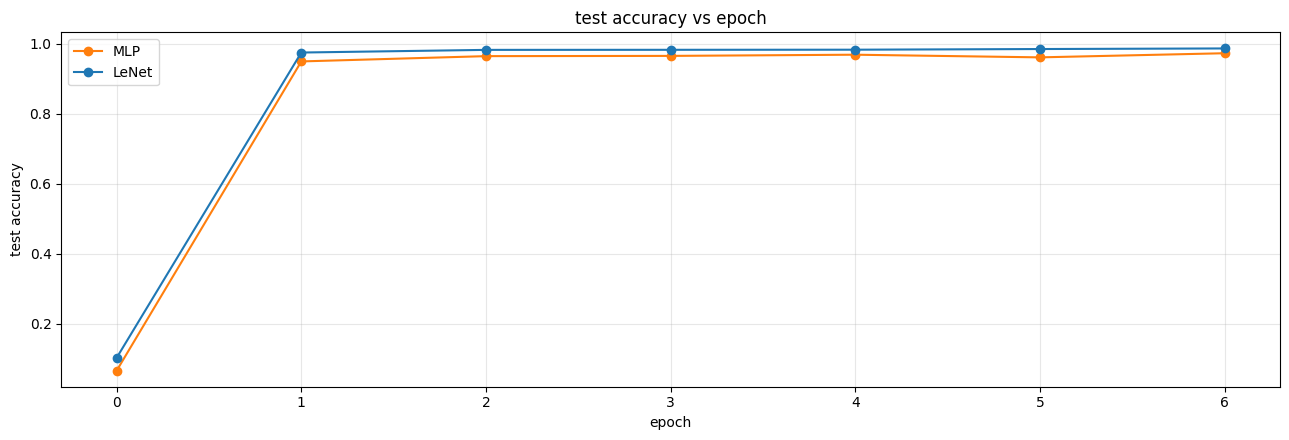

MLP  :  61,842 parameters,  test accuracy 0.9736
LeNet:  61,706 parameters,  test accuracy 0.9873


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(13, 4.5))

axes.plot(mlp_history, "o-", color="tab:orange", label="MLP")
axes.plot(lenet_history, "o-", color="tab:blue", label="LeNet")
axes.set_xlabel("epoch")
axes.set_ylabel("test accuracy")
axes.set_title("test accuracy vs epoch")
axes.grid(alpha=0.3)
axes.legend()
fig.tight_layout()
plt.show()

print(
    f"MLP  : {count_params(mlp):>7,d} parameters,  test accuracy {mlp_history[-1]:.4f}"
)
print(
    f"LeNet: {count_params(lenet):>7,d} parameters,  test accuracy {lenet_history[-1]:.4f}"
)

### What LeNet learned

Recall §2: kernels such as Sobel were *designed* by hand. LeNet **learned** its kernels from the data alone. Below are the six $5 \times 5$ filters of its first convolutional layer (`c1`) after training. The network discovered its own edge- and blob-detectors — much as Hubel and Wiesel's simple cells respond to oriented edges, and much like the hand-designed kernels of §2, but fitted to the task rather than chosen.

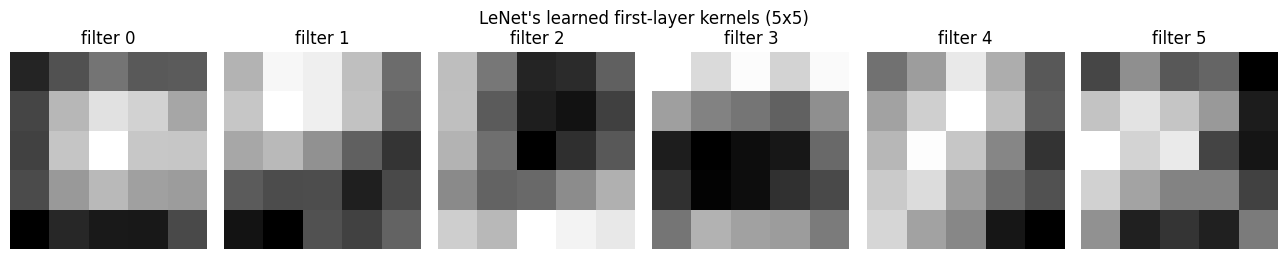

In [29]:
filters = lenet.c1.weight.detach().cpu()  # shape (6, 1, 5, 5): 6 learned kernels

fig, axes = plt.subplots(1, 6, figsize=(13, 2.6))
for i, ax in enumerate(axes):
    ax.imshow(filters[i].squeeze(), cmap="gray")
    ax.set_title(f"filter {i}")
    ax.axis("off")
fig.suptitle("LeNet's learned first-layer kernels (5x5)")
fig.tight_layout()
plt.show()

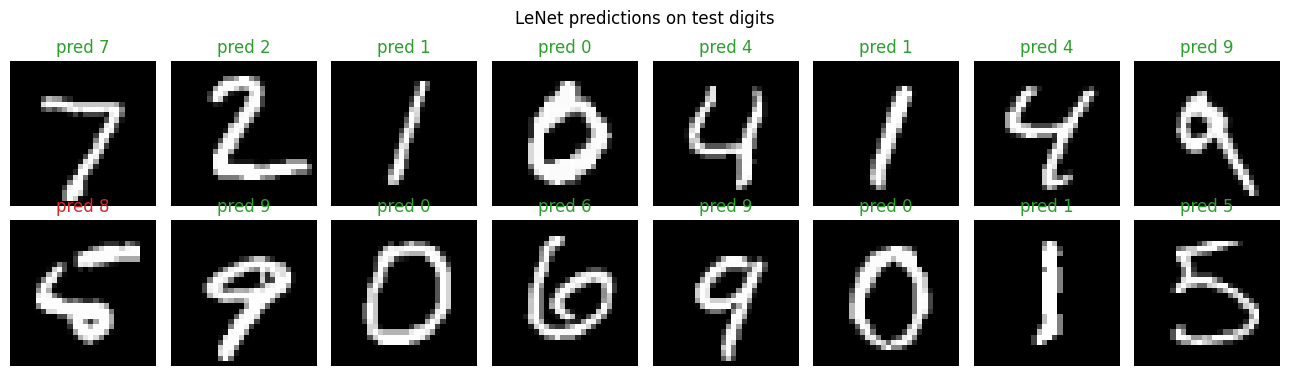

In [30]:
# LeNet predictions on the first 16 test digits — green title = correct, red = wrong.
lenet.eval()
imgs = torch.stack([test_set[i][0] for i in range(16)])
labels = [test_set[i][1] for i in range(16)]
with torch.no_grad():
    preds = lenet(imgs.to(DEVICE)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(13, 3.8))
for ax, img, label, pred in zip(axes.ravel(), imgs, labels, preds):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(
        f"pred {pred.item()}", color="tab:green" if pred.item() == label else "tab:red"
    )
    ax.axis("off")
fig.suptitle("LeNet predictions on test digits")
fig.tight_layout()
plt.show()

## §5 — Homework

Four extensions, in increasing order of effort.

1. **"Same" padding.** Write a helper that, given a kernel size $K$, stride $1$ and dilation $d$, returns the padding that keeps the output the same size as the input. Verify it on `conv2d` for a few kernels.

2. **Multi-channel convolution.** Generalise `conv2d` to `conv2d_multi(X, K)` where `X` has shape `(C_in, H, W)` and `K` has shape `(C_out, C_in, kh, kw)`. Each output channel sums a convolution over all input channels; the result has shape `(C_out, H_out, W_out)`. Test it on the RGB Grace Hopper image ($C_{\text{in}} = 3$).

3. **A learned kernel.** Pick a target output — for instance, take $Z = \text{conv2d}(\text{image}, K_{\text{Sobel-x}})$ as a "label". Forget the kernel that produced it, and try to *recover* it: treat the $9$ kernel entries as unknowns and minimise $\lVert \text{conv2d}(\text{image}, K) - Z \rVert^2$ with the gradient descent of notebook 2. This is, in miniature, what training a convolutional layer does.

4. **Data augmentation.** A classifier should recognise a digit regardless of a small shift or rotation — the lecture calls this *invariance*. One way to encourage it is **data augmentation**: applying random transformations to the training images. With `torchvision` this is a one-line change to the transform, e.g.

   ```python
   transform = transforms.Compose([
       transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
       transforms.ToTensor(),
   ])
   ```

   Retrain `LeNet` with the augmented training set and check whether the test accuracy improves.

## Closing thoughts

Three ideas to take away.

- **Inductive bias is power.** A convolutional layer has *far fewer* parameters than a fully-connected one (Exercise 0), yet works better on images. The gain comes not from capacity but from *structure*: locality and weight sharing match how images are actually organised. The bias is wired into the architecture, not learned.
- **The brain was a useful prior.** Hubel and Wiesel's V1 $\to$ V2 $\to$ IT hierarchy of edge- and shape-detectors is, structurally, what a deep CNN does. The biology did not dictate the design, but it pointed in the right direction.
- **Tacit knowledge in weights.** The hand-designed kernels here are interpretable — we can name what each does. A trained CNN's kernels are not chosen but *learned*, and the early ones often rediscover edge detectors much like Sobel's. The "rules" are real, but they live in millions of numbers rather than in words.

These pieces — convolution, activation, channels, pooling, and a final fully-connected classifier — were first combined in LeCun's **LeNet-5** (1998) — the network you implemented and trained in §4 — the architectural template every CNN since has inherited.